<a href="https://colab.research.google.com/github/BJut7021/TH_DeepLearning/blob/main/TH_DL_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikeras

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras.models import Sequential

from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier # Corrected import
from keras.layers import Dropout

from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler


**3.2. Đọc tập dữ liệu FASHION MNIST**

In [ ]:
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


**3.3. Xử lý dữ liệu**

In [ ]:
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape((10000,784))

minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:',len(np.unique(y_train)))
print('Classes:',np.unique (y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


**3.4. Trực quan hóa dữ liệu**

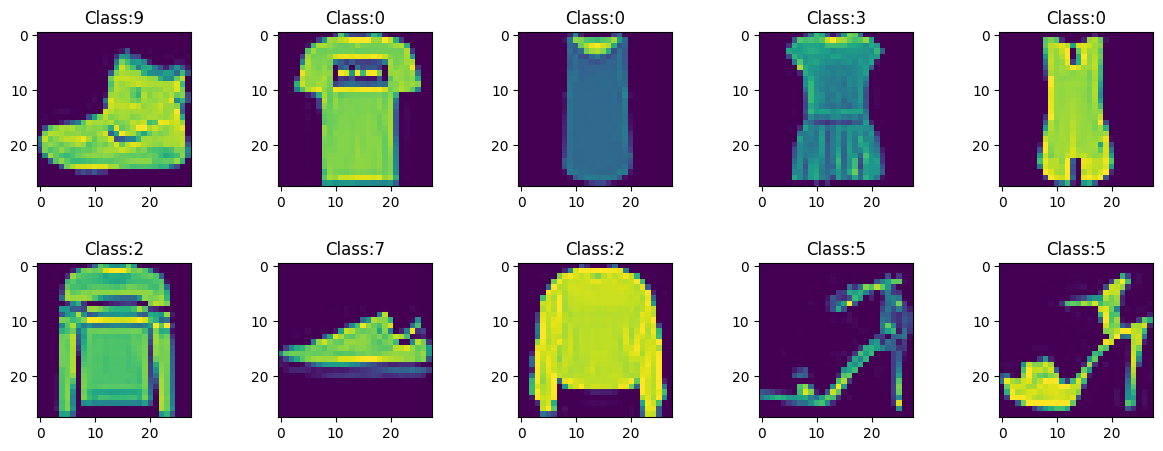

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28,28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

**3.5. Xây dựng mô hình học ANN**

In [ ]:

fashion_model = Sequential()

fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform',activation='relu'))

fashion_model.add(Dense(units=10,kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

**3.6. Huấn luyện ANN model**


In [ ]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8208 - loss: 0.5078 - val_accuracy: 0.8572 - val_loss: 0.3959
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8662 - loss: 0.3725 - val_accuracy: 0.8713 - val_loss: 0.3587
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8794 - loss: 0.3299 - val_accuracy: 0.8725 - val_loss: 0.3586
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8861 - loss: 0.3060 - val_accuracy: 0.8812 - val_loss: 0.3217
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8952 - loss: 0.2864 - val_accuracy: 0.8820 - val_loss: 0.3271
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8991 - loss: 0.2721 - val_accuracy: 0.8805 - val_loss: 0.3495
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9047 - loss: 0.2588 - val_accuracy: 0.8793 - val_loss: 0.3351
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9068 - loss:

**3.7. Đánh giá ANN model**

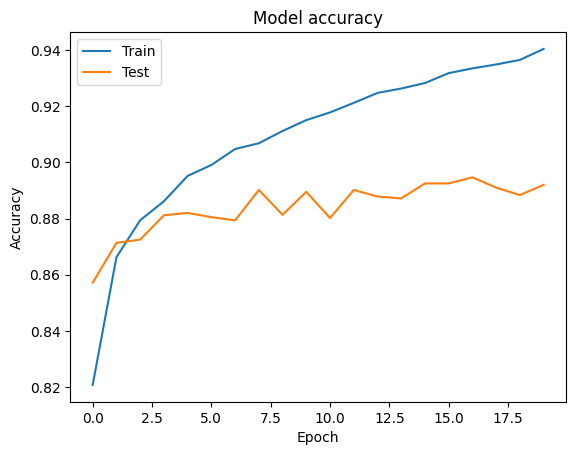

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


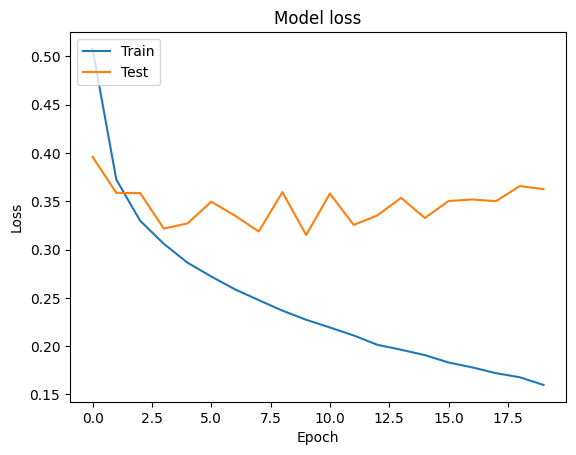

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

**3.8. Dự báo ảnh mới**

In [ ]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


**3.9. Đọc tập dữ liệu từ file**

In [ ]:
mnist_train_path = 'https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/crabs.csv'
mnist_test_path = 'https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/babies.csv'
mnist_train = pd.read_csv(mnist_train_path, sep=r'\s+', engine='python', na_values=['NA']) # Use raw URL and specify space as delimiter
mnist_test = pd.read_csv(mnist_test_path, sep=r'\s+', engine='python', na_values=['NA']) # Use raw URL and specify space as delimiter


print(mnist_train.head())
print(mnist_test.shape)

   presz  postsz   inc  year  lf
0  113.6   127.7  14.1   NaN   0
1  118.1   133.2  15.1   NaN   0
2  119.9   135.3  15.4   NaN   0
3  126.2   143.3  17.1   NaN   0
4  126.7   139.3  12.6   NaN   0
(1236, 2)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# We will use mnist_train (crabs.csv) for both training and testing.
# Make a copy to avoid SettingWithCopyWarning
data_crabs = mnist_train.copy()

# Fill NaN values in 'year' column with the median
# The 'year' column contains integer-like values, so median is appropriate.
median_year = data_crabs['year'].median()
data_crabs['year'].fillna(median_year, inplace=True)
data_crabs['year'] = data_crabs['year'].astype(int) # Convert to int if desired

# Extract features (X) and target (y) from crabs.csv
# Features are 'presz', 'postsz', 'inc', 'year'
X = data_crabs.iloc[:, :-1] # All columns except the last ('lf')
y = data_crabs.iloc[:, -1]  # Last column ('lf') as target

# Perform a train-test split on the crabs.csv data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Added stratify=y to ensure both classes are present in train/test splits

# y (lf column) contains 0s and 1s, which are already 0-indexed and appropriate for binary classification.
# LabelEncoder is not strictly needed here as labels are already 0 and 1.

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print('Number of classes (y_train):', len(np.unique(y_train)))
print('Classes (y_train encoded):', np.unique(y_train))

X_train shape: (377, 4)
y_train shape: (377,)
X_test shape: (95, 4)
y_test shape: (95,)
Number of classes (y_train): 2
Classes (y_train encoded): [0 1]


/tmp/ipykernel_10850/1460908316.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_crabs['year'].fillna(median_year, inplace=True)


In [ ]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense


In [ ]:
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform',activation='relu'))
# For binary classification (labels 0 and 1), use 1 unit with 'sigmoid' activation
model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))
# For 1 unit with 'sigmoid' activation, use 'binary_crossentropy' loss
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_fit = model.fit(X_train , y_train, epochs=30, verbose=1)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7639 - loss: 0.5987
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7507 - loss: 0.6086 
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7215 - loss: 0.5682 
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7639 - loss: 0.4804 
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7692 - loss: 0.4727 
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7613 - loss: 0.4816 
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7692 - loss: 0.4526 
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7560 - loss: 0.4423
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8196 - loss: 0.4351 
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7825 - loss: 0.4535 
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7719 - loss: 0.4389
Epoch 12/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7

In [ ]:
predicted_label = np.round(model.predict(X_test)[0])
actual_label = y_test.iloc[0]
print(predicted_label, actual_label)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[1.] 1


In [ ]:
img_path = r'/content/696249800_18089713175255130_453296426341664759_n.jpg'
img_size = (28,28)
img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size, color_mode='grayscale')
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array,(784))
img_array = tf.expand_dims(img,0)
img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)
print(img_array.shape)

img_predict = fashion_model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]
8


**Bài tập**

Kích thước tập huấn luyện: (50000, 32, 32, 3)
Kích thước tập kiểm tra: (10000, 32, 32, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.3223 - loss: 1.8777 - val_accuracy: 0.3839 - val_loss: 1.7214
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.3986 - loss: 1.6799 - val_accuracy: 0.3852 - val_loss: 1.7279
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4286 - loss: 1.5870 - val_accuracy: 0.4478 - val_loss: 1.5662
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.4516 - loss: 1.5335 - val_accuracy: 0.4594 - val_loss: 1.5078
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.4696 - loss: 1.4838 - val_accuracy: 0.4723 - val_loss: 1.4857
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.4838 - loss: 1.4496 - val_accuracy: 0.4725 - val_loss: 1.4846
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.4901 - loss: 1.4218 - val_accuracy: 0.4852 - val_loss: 1.4629
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.4986 - loss: 1.3941 - 

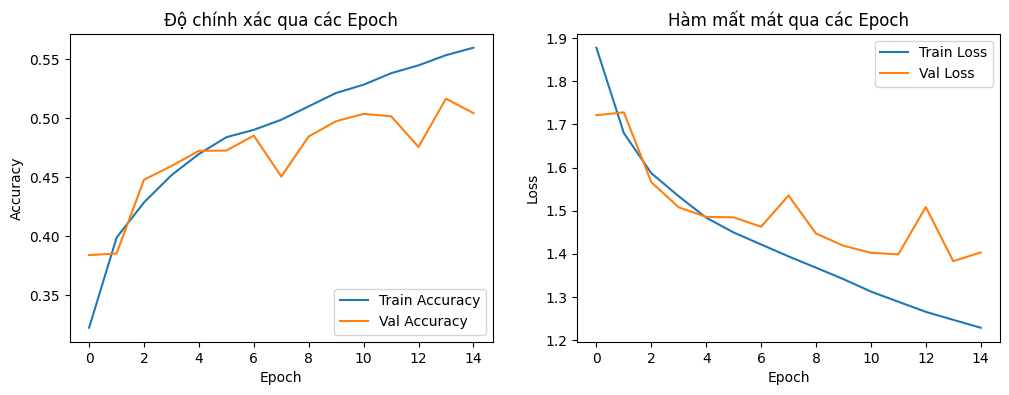

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


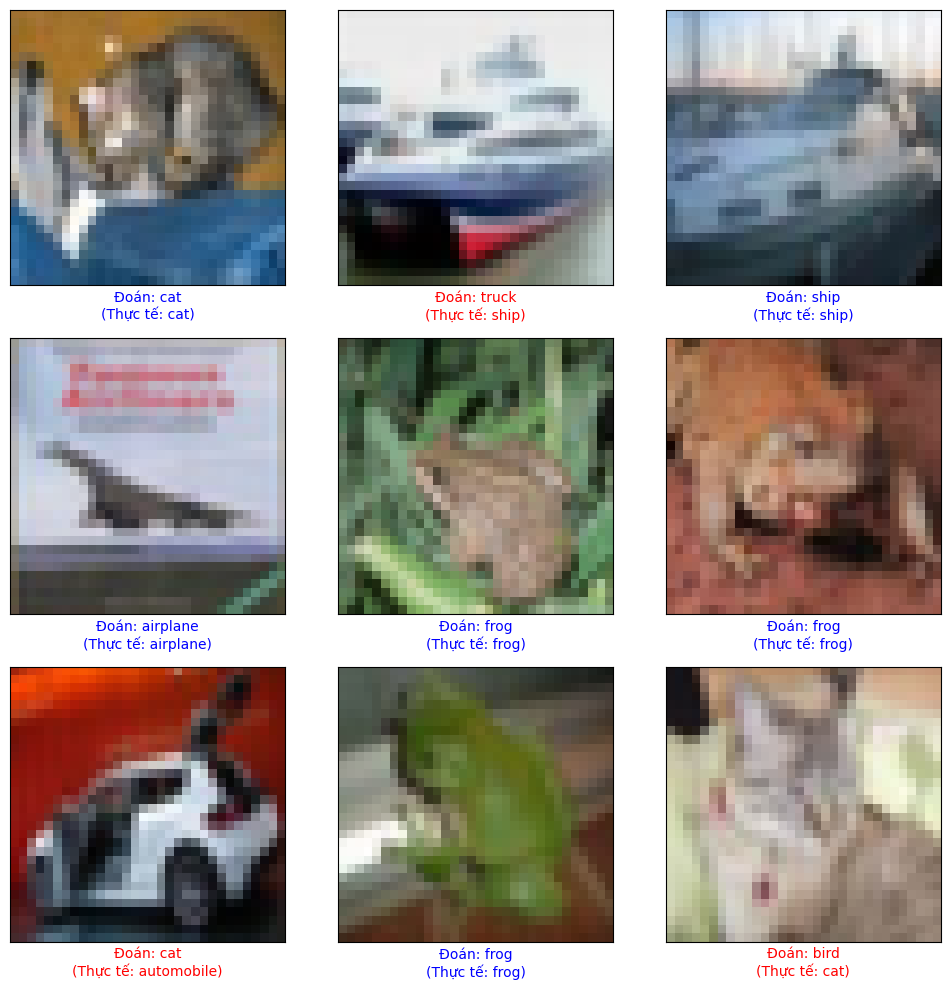

In [ ]:
#BT1
# 1. Khai báo các thư viện cần thiết
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 2. Tải và chuẩn bị bộ dữ liệu CIFAR-10 từ TensorFlow
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Chuẩn hóa dữ liệu pixel về khoảng [0, 1] để mô hình hội tụ tốt hơn
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Định nghĩa danh sách các nhãn tương ứng theo yêu cầu đề bài
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Kiểm tra kích thước dữ liệu
print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

# 3. Xây dựng cấu trúc mạng ANN (Mạng phẳng)
model = models.Sequential([
    # Làm phẳng hình ảnh từ kích thước (32, 32, 3) thành một vector phẳng 3072 phần tử
    layers.Flatten(input_shape=(32, 32, 3)),

    # Lớp ẩn thứ nhất (Dense) với hàm kích hoạt ReLU
    layers.Dense(512, activation='relu'),

    # Lớp ẩn thứ hai
    layers.Dense(256, activation='relu'),

    # Lớp ẩn thứ ba
    layers.Dense(128, activation='relu'),

    # Lớp đầu ra (Output layer) với 10 nút tương ứng với 10 lớp nhãn
    layers.Dense(10)
])

# Hiển thị cấu trúc chi tiết của mô hình mạng
model.summary()

# 4. Biên dịch mô hình (Compile)
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 5. Huấn luyện mô hình (Train) trên Colab
# Ở đây đặt epochs=15 để tiết kiệm thời gian, bạn có thể tăng lên nếu muốn độ chính xác cao hơn
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# 6. Đánh giá độ chính xác trên tập kiểm tra (Test set)
test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)
print(f"\nĐộ chính xác trên tập kiểm tra (Test Accuracy): {test_acc * 100:.2f}%")

# 7. Trực quan hóa kết quả huấn luyện (Đồ thị Loss và Accuracy)
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Độ chính xác qua các Epoch')

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Hàm mất mát qua các Epoch')

plt.show()

# 8. Dự đoán thử một vài hình ảnh ngẫu nhiên từ tập kiểm tra
predictions = model.predict(X_test)
score = tf.nn.softmax(predictions) # Chuyển đổi logits sang xác suất (probability)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i])

    predicted_label = np.argmax(score[i])
    true_label = y_test[i][0]

    # Màu xanh nếu đoán đúng, màu đỏ nếu đoán sai
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"Đoán: {class_names[predicted_label]}\n(Thực tế: {class_names[true_label]})", color=color)
plt.tight_layout()
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Kích thước tập huấn luyện: (60000, 28, 28)
Kích thước tập kiểm tra: (10000, 28, 28)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.9319 - loss: 0.2322 - val_accuracy: 0.9614 - val_loss: 0.1224
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9724 - loss: 0.0891 - val_accuracy: 0.9723 - val_loss: 0.0833
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9814 - loss: 0.0582 - val_accuracy: 0.9769 - val_loss: 0.0746
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9855 - loss: 0.0439 - val_accuracy: 0.9761 - val_loss: 0.0720
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9896 - loss: 0.0329 - val_accuracy: 0.9737 - val_loss: 0.0901
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.9912 - loss: 0.0271 - val_accuracy: 0.9766 - val_loss: 0.0808
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9922 - loss: 0.0232 - val_accuracy: 0.9808 - val_loss: 0.0664
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9937 - loss: 0.0187 - val_accura

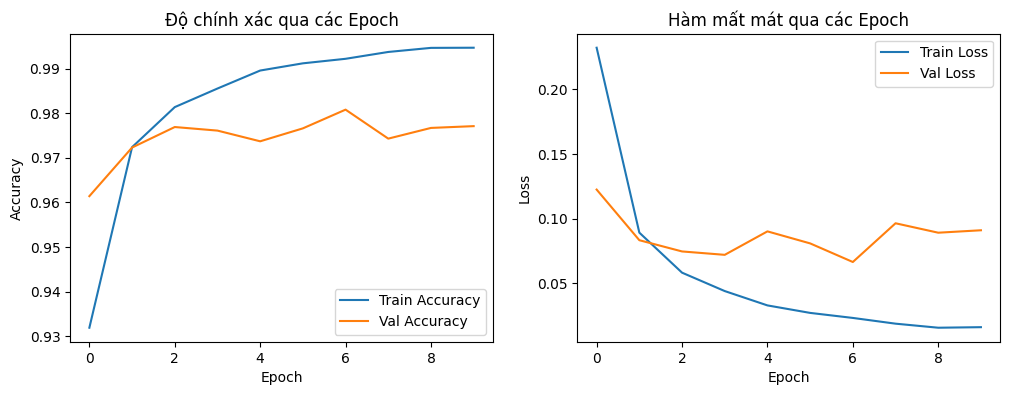

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


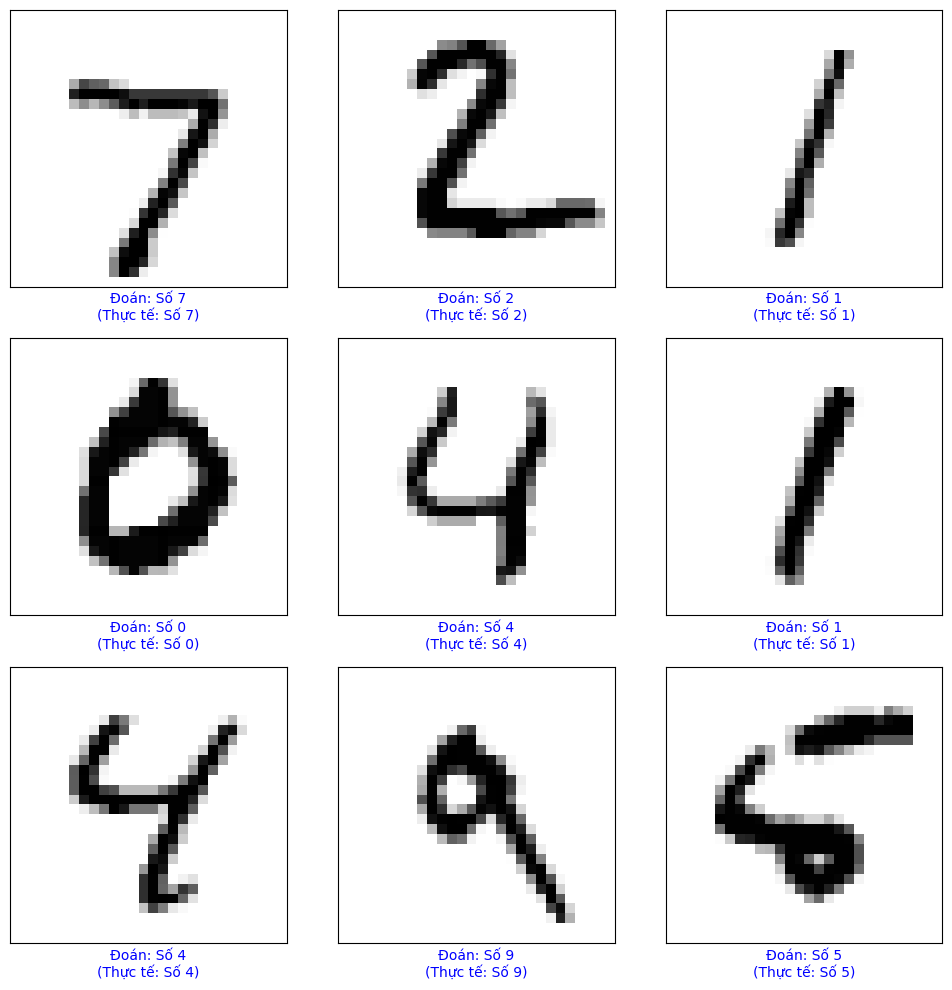

In [3]:
# 1. Khai báo các thư viện cần thiết
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 2. Tải và chuẩn bị bộ dữ liệu MNIST từ TensorFlow (như yêu cầu trong image_bdd2a4.png)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Chuẩn hóa dữ liệu ảnh xám về khoảng [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Định nghĩa danh sách các nhãn tương ứng theo bảng trong ảnh image_bdd2a4.png
class_names = ['Số 0', 'Số 1', 'Số 2', 'Số 3', 'Số 4',
               'Số 5', 'Số 6', 'Số 7', 'Số 8', 'Số 9']

# Kiểm tra kích thước hình ảnh (MNIST là ảnh xám kích thước 28x28)
print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

# 3. Xây dựng cấu trúc mạng ANN (Mạng phẳng)
model = models.Sequential([
    # Làm phẳng hình ảnh từ kích thước ảnh xám (28, 28) thành một vector phẳng 784 phần tử
    layers.Flatten(input_shape=(28, 28)),

    # Lớp ẩn thứ nhất (Dense) với hàm kích hoạt ReLU
    layers.Dense(256, activation='relu'),

    # Lớp ẩn thứ hai
    layers.Dense(128, activation='relu'),

    # Lớp đầu ra (Output layer) gồm 10 nút phân loại ứng với các nhãn từ Số 0 đến Số 9
    layers.Dense(10)
])

# Hiển thị cấu trúc mạng mạng vừa khởi tạo
model.summary()

# 4. Biên dịch mô hình (Compile)
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 5. Huấn luyện mô hình (Train) trên Colab
# Bộ dữ liệu MNIST khá dễ học nên chỉ cần chạy khoảng 10 epochs là đạt kết quả rất cao
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# 6. Đánh giá độ chính xác trên tập kiểm tra (Test set)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nĐộ chính xác trên tập kiểm tra (Test Accuracy): {test_acc * 100:.2f}%")

# 7. Trực quan hóa kết quả đồ thị Loss và Accuracy
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Độ chính xác qua các Epoch')

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Hàm mất mát qua các Epoch')

plt.show()

# 8. Dự đoán thử một vài chữ số ngẫu nhiên từ tập kiểm tra
predictions = model.predict(X_test)
score = tf.nn.softmax(predictions)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i], cmap=plt.cm.binary) # Hiển thị ảnh đen trắng dạng nhị phân

    predicted_label = np.argmax(score[i])
    true_label = y_test[i]

    # Màu xanh nếu đoán đúng, màu đỏ nếu đoán sai
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"Đoán: {class_names[predicted_label]}\n(Thực tế: {class_names[true_label]})", color=color)
plt.tight_layout()
plt.show()